In [1]:
from google.colab import drive
drive.mount('/content/drive')

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

In [ ]:
import os

if not os.path.exists("/content/new_top5_dataset"):
    !cp /content/drive/MyDrive/new_top5_dataset.tar /content/
    !tar -xf /content/new_top5_dataset.tar

DATASET_ROOT = "/content/content/new_top5_dataset"

In [9]:
!ls /kaggle/input/datasets/mithilesh2303

new-top5-dataset


In [6]:
import os

DATASET_ROOT = "/kaggle/input/datasets/mithilesh2303/new-top5-dataset/content/new_top5_dataset"

print("Dataset folders:", os.listdir(DATASET_ROOT))

Dataset folders: ['val', 'test', 'train']


In [7]:
import json
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 5

Device: cuda


In [21]:
CATEGORY_MAP = {
    1:0,   # short sleeve top
    2:1,   # long sleeve top
    7:2,   # shorts
    8:3,   # trousers
    9:4    # skirt
}

def build_label(annotation):

    label = torch.zeros(NUM_CLASSES)

    for k in annotation:
        if k.startswith("item"):
            cid = annotation[k]["category_id"]

            if cid in CATEGORY_MAP:
                label[CATEGORY_MAP[cid]] = 1

    return label

In [22]:
class ClothingDataset(Dataset):

    def __init__(self,img_dir,ann_dir,transform):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):

        img_name = self.files[idx]

        img_path = os.path.join(self.img_dir,img_name)
        ann_path = os.path.join(self.ann_dir,img_name.replace(".jpg",".json"))

        image = Image.open(img_path).convert("RGB")

        with open(ann_path) as f:
            ann = json.load(f)

        label = build_label(ann)

        return self.transform(image), label

In [23]:
transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [24]:
train_dataset = ClothingDataset(
    os.path.join(DATASET_ROOT,"train","images"),
    os.path.join(DATASET_ROOT,"train","annotations"),
    transform
)

val_dataset = ClothingDataset(
    os.path.join(DATASET_ROOT,"val","images"),
    os.path.join(DATASET_ROOT,"val","annotations"),
    transform
)

test_dataset = ClothingDataset(
    os.path.join(DATASET_ROOT,"test","images"),
    os.path.join(DATASET_ROOT,"test","annotations"),
    transform
)

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True,num_workers=4,pin_memory=True)
val_loader = DataLoader(val_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

print("Train size:",len(train_dataset))
print("Val size:",len(val_dataset))
print("Test size:",len(test_dataset))

Train size: 100921
Val size: 21626
Test size: 21627


In [25]:
from torch.utils.data import Subset
import random

subset_size = int(0.5 * len(train_dataset))

indices = random.sample(range(len(train_dataset)), subset_size)

train_dataset = Subset(train_dataset, indices)

print("Subset train size:", len(train_dataset))

Subset train size: 50460


In [26]:
import torchvision.models as models

model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [27]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 10

In [28]:
from tqdm import tqdm

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    loop = tqdm(train_loader)

    for images,labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs,labels)

            val_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )

Epoch [1/10]: 100%|██████████| 6308/6308 [09:00<00:00, 11.66it/s, loss=0.551]


Epoch 1/10 | Train Loss: 0.5659 | Val Loss: 0.5108


Epoch [2/10]: 100%|██████████| 6308/6308 [09:01<00:00, 11.65it/s, loss=0.486]


Epoch 2/10 | Train Loss: 0.4909 | Val Loss: 0.4414


Epoch [3/10]: 100%|██████████| 6308/6308 [08:58<00:00, 11.71it/s, loss=0.5]  


...

Epoch 8/10 | Train Loss: 0.2875 | Val Loss: 0.2884


Epoch [9/10]: 100%|██████████| 6308/6308 [08:57<00:00, 11.73it/s, loss=0.339] 


Epoch 9/10 | Train Loss: 0.2703 | Val Loss: 0.2840


Epoch [10/10]: 100%|██████████| 6308/6308 [08:58<00:00, 11.71it/s, loss=0.201] 


Epoch 10/10 | Train Loss: 0.2572 | Val Loss: 0.2766


In [29]:
import numpy as np

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():

    for images,labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_preds.append(probs.cpu())
        all_targets.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

y_pred = (all_preds > 0.5).astype(int)
y_true = all_targets

100%|██████████| 676/676 [04:57<00:00,  2.27it/s]


In [30]:
from sklearn.metrics import classification_report

class_names = [
    "short_sleeve_top",
    "long_sleeve_top",
    "shorts",
    "trousers",
    "skirt"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

                  precision    recall  f1-score   support

short_sleeve_top       0.83      0.81      0.82     10588
 long_sleeve_top       0.78      0.55      0.65      5370
          shorts       0.85      0.81      0.83      5380
        trousers       0.89      0.90      0.90      8201
           skirt       0.79      0.62      0.69      4569

       micro avg       0.84      0.76      0.80     34108
       macro avg       0.83      0.74      0.78     34108
    weighted avg       0.84      0.76      0.80     34108
     samples avg       0.80      0.77      0.77     34108



In [31]:
from sklearn.metrics import f1_score

micro_f1 = f1_score(y_true,y_pred,average="micro")
macro_f1 = f1_score(y_true,y_pred,average="macro")

print("Micro F1:",micro_f1)
print("Macro F1:",macro_f1)

Micro F1: 0.8012346058167746
Macro F1: 0.7774960169249714


In [20]:
from collections import Counter

counter = Counter()
test_annotation_dir = os.path.join(DATASET_ROOT, "test", "annotations")
for file in os.listdir(test_annotation_dir):
    with open(os.path.join(test_annotation_dir, file)) as f:
        data = json.load(f)

    for k in data:
        if k.startswith("item"):
            counter[data[k]["category_id"]] += 1

print(counter)

Counter({1: 10740, 8: 8256, 7: 5422, 2: 5419, 9: 4606})


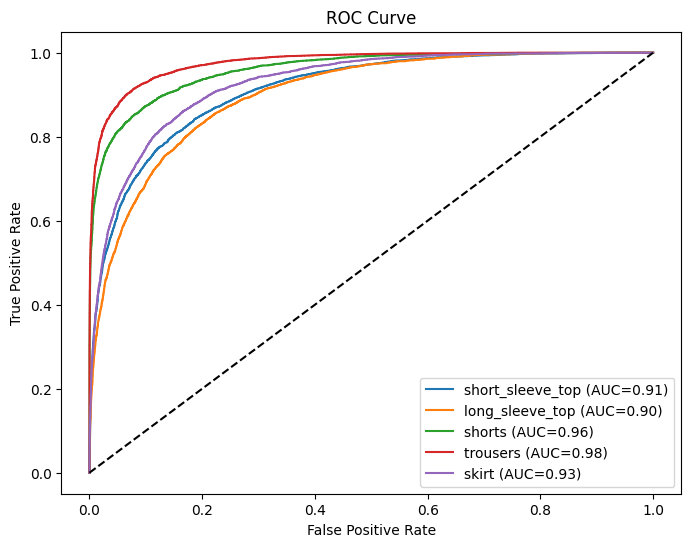

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true[:,i],all_preds[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(y_true,all_preds,average="macro")
micro_auc = roc_auc_score(y_true,all_preds,average="micro")

print("Macro AUC:",macro_auc)
print("Micro AUC:",micro_auc)

Macro AUC: 0.9351071596743621
Micro AUC: 0.9429112291015742


In [35]:
# Save model in Kaggle working directory
model_path = "/kaggle/working/efficientnet_scratch.pth"

torch.save(model.state_dict(), model_path)

print("Model saved:", model_path)

Model saved: /kaggle/working/efficientnet_scratch.pth
